# Twitch Channel Growth — Feature Engineering & Regression Modeling

**Notebook 2 of 2**

This notebook picks up from the cleaned dataset produced in Notebook 1
(`twitch_cleaned.csv`) and covers:

1. Feature engineering (ratios, log transforms, categorical encoding)
2. Train / test split
3. Baseline and advanced regression models (Linear, Ridge, Lasso, Random Forest, Gradient Boosting)
4. Model comparison and selection
5. **Overfitting checks**: train vs. test performance, cross-validation, learning curves
6. Feature importance and residual diagnostics
7. Final model summary


In [1]:

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.facecolor'] = 'white'
RANDOM_STATE = 42

df = pd.read_csv('twitch_cleaned.csv')
print(df.shape)
df.head()


(1000, 11)


## 1. Feature Engineering


**Target variable:** `Followers gained` — the clearest available measure of channel growth.

Because it can be (rarely) negative, we model it on a **signed-log scale**
(`sign(y) * log1p(|y|)`), which compresses the heavy right skew we saw in Notebook 1 while
still preserving the sign for the 3 churn cases, then we back-transform predictions for
evaluation in original units.

**Engineered features:**
- Log-transformed versions of all skewed numeric predictors
- **Engagement ratios** that normalize for channel size / activity, which raw totals can't
  capture:
  - `avg_to_peak_ratio` = Average viewers / Peak viewers (audience consistency)
  - `watch_per_stream_minute` = Watch time / Stream time (stickiness per minute streamed)
  - `views_per_follower` = Views gained / Followers (discovery efficiency)
  - `minutes_per_stream_day` proxy via stream time itself (kept as log feature)
- Categorical encoding: `Partnered`, `Mature` as 0/1; `Language` grouped into top categories
  + "Other" and one-hot encoded (avoids an explosion of sparse dummy columns).


In [2]:

feat = df.copy()

# --- Signed-log target ---
feat['growth_target'] = np.sign(feat['Followers gained']) * np.log1p(feat['Followers gained'].abs())

# --- Log-transformed predictors (all non-negative by construction) ---
for col in ['Watch time(Minutes)', 'Stream time(minutes)', 'Peak viewers',
            'Average viewers', 'Views gained', 'Followers']:
    feat[f'log_{col}'] = np.log1p(feat[col])

# --- Engagement / efficiency ratios ---
feat['avg_to_peak_ratio'] = feat['Average viewers'] / feat['Peak viewers'].replace(0, np.nan)
feat['watch_per_stream_minute'] = feat['Watch time(Minutes)'] / feat['Stream time(minutes)'].replace(0, np.nan)
feat['views_per_follower'] = feat['Views gained'] / feat['Followers'].replace(0, np.nan)

feat[['avg_to_peak_ratio', 'watch_per_stream_minute', 'views_per_follower']] = \
    feat[['avg_to_peak_ratio', 'watch_per_stream_minute', 'views_per_follower']].fillna(0)

# --- Categorical encoding ---
feat['Partnered'] = feat['Partnered'].astype(int)
feat['Mature'] = feat['Mature'].astype(int)

top_languages = feat['Language'].value_counts().head(6).index.tolist()
feat['Language_grouped'] = feat['Language'].where(feat['Language'].isin(top_languages), 'Other')
lang_dummies = pd.get_dummies(feat['Language_grouped'], prefix='lang', drop_first=True)
feat = pd.concat([feat, lang_dummies], axis=1)

print(f"Top languages kept individually: {top_languages}")
print(f"Engineered feature set shape: {feat.shape}")
feat.head()


Top languages kept individually: ['English', 'Korean', 'Russian', 'Spanish', 'French', 'Portuguese']
Engineered feature set shape: (1000, 28)


In [3]:

feat[['avg_to_peak_ratio', 'watch_per_stream_minute', 'views_per_follower']].describe()


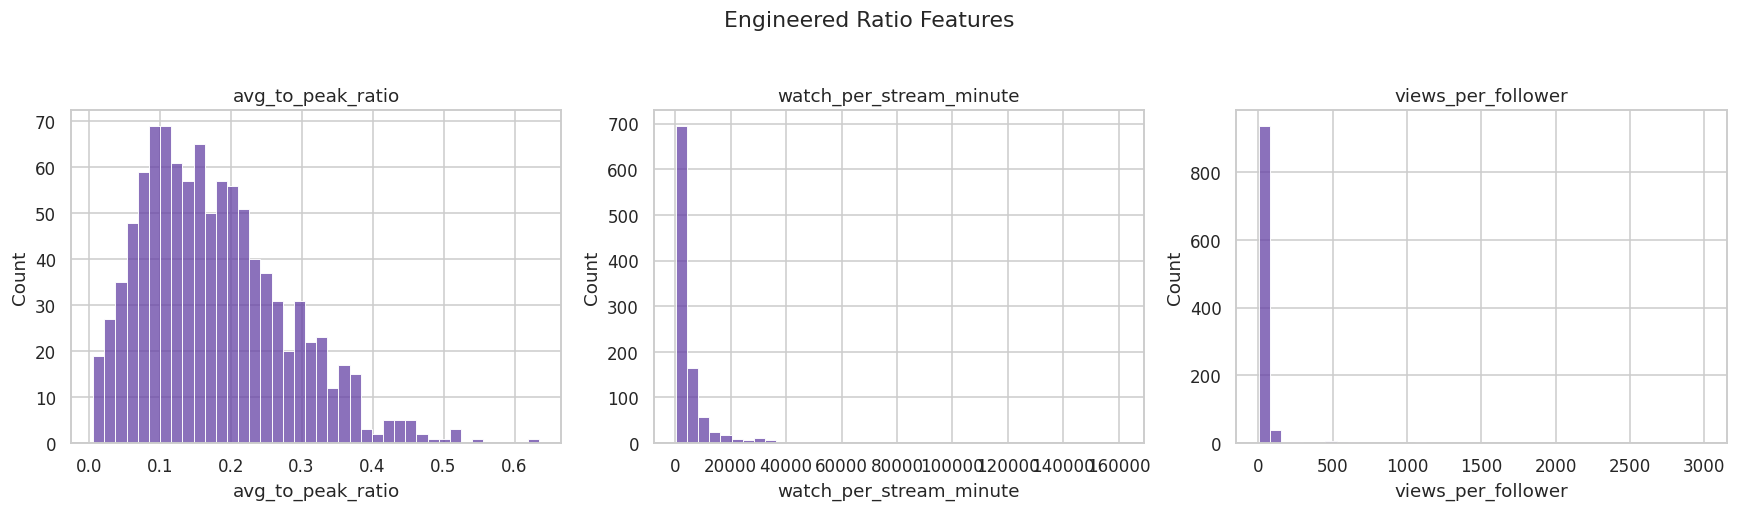

In [4]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ['avg_to_peak_ratio', 'watch_per_stream_minute', 'views_per_follower']):
    sns.histplot(feat[col], bins=40, ax=ax, color='#6441A5')
    ax.set_title(col)
plt.suptitle('Engineered Ratio Features', y=1.03)
plt.tight_layout()
plt.show()



**⚠️ Leakage check.** `Followers` (current total audience size) is extremely predictive of
`Followers gained` (r ≈ 0.7, see Notebook 1) but it is measured at the *same snapshot* as the
target — a channel's current follower count already partly *contains* the followers it just
gained. Using it risks the model simply learning "big channels stay big" rather than genuine
growth drivers, and inflates apparent performance without real-world actionability (you can't
"increase your Followers" as a lever independent of gaining followers).

We therefore build **two candidate feature sets**:
- **Set A (with `Followers`)** — best raw predictive power, useful as an upper-bound benchmark.
- **Set B (without `Followers`)** — a more honest "activity-driven growth" model based only on
  streaming behavior (watch time, stream time, viewers, views gained, partnered/mature/language),
  which is more useful for actionable insight (Notebook 2's primary model).

We carry both forward and compare.


In [5]:

base_features = ['log_Watch time(Minutes)', 'log_Stream time(minutes)', 'log_Peak viewers',
                  'log_Average viewers', 'log_Views gained', 'avg_to_peak_ratio',
                  'watch_per_stream_minute', 'views_per_follower', 'Partnered', 'Mature'] \
                  + list(lang_dummies.columns)

feature_set_A = base_features + ['log_Followers']   # includes current audience size
feature_set_B = base_features                        # activity-only, no audience-size leakage

X_A = feat[feature_set_A]
X_B = feat[feature_set_B]
y = feat['growth_target']

print(f"Set A ({len(feature_set_A)} features): includes log_Followers")
print(f"Set B ({len(feature_set_B)} features): activity-only")


Set A (17 features): includes log_Followers
Set B (16 features): activity-only


## 2. Train / Test Split

In [6]:

X_A_train, X_A_test, y_train, y_test = train_test_split(X_A, y, test_size=0.2, random_state=RANDOM_STATE)
X_B_train, X_B_test, _, _ = train_test_split(X_B, y, test_size=0.2, random_state=RANDOM_STATE)
# (y_train/y_test are identical across splits since we use the same random_state & index order)

print(f"Train size: {X_A_train.shape[0]}  |  Test size: {X_A_test.shape[0]}")


Train size: 800  |  Test size: 200


## 3. Model Training & Comparison

In [7]:

def build_estimator(model, scale):
    # Wrapping scaled models in a Pipeline guarantees the SAME scaler (fit only on
    # training data) is automatically applied at both training time and any later
    # prediction time -- avoiding a common bug where a model trained on scaled data
    # is accidentally later called with raw, unscaled inputs.
    if scale:
        return Pipeline([('scaler', StandardScaler()), ('model', model)])
    return model

def evaluate_model(name, model, X_train, X_test, y_train, y_test, scale=False):
    estimator = build_estimator(model, scale)
    estimator.fit(X_train, y_train)
    pred_train = estimator.predict(X_train)
    pred_test = estimator.predict(X_test)

    result = {
        'model': name,
        'train_R2': r2_score(y_train, pred_train),
        'test_R2': r2_score(y_test, pred_test),
        'test_MAE': mean_absolute_error(y_test, pred_test),
        'test_RMSE': np.sqrt(mean_squared_error(y_test, pred_test)),
        'cv_R2_mean': cross_val_score(estimator, X_train, y_train, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE), scoring='r2').mean(),
    }
    result['overfit_gap'] = result['train_R2'] - result['test_R2']
    return result, estimator


In [8]:

models_to_try = {
    'Linear Regression': (LinearRegression(), True),
    'Ridge (alpha=1.0)': (Ridge(alpha=1.0, random_state=RANDOM_STATE), True),
    'Lasso (alpha=0.01)': (Lasso(alpha=0.01, random_state=RANDOM_STATE, max_iter=10000), True),
    'Random Forest': (RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=4, random_state=RANDOM_STATE), False),
    'Gradient Boosting': (GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE), False),
}

results_A, fitted_A = [], {}
for name, (model, scale) in models_to_try.items():
    res, fitted = evaluate_model(name, model, X_A_train, X_A_test, y_train, y_test, scale=scale)
    results_A.append(res)
    fitted_A[name] = fitted

results_A_df = pd.DataFrame(results_A).set_index('model').round(3)
print("=== Feature Set A (includes current Followers) ===")
results_A_df


=== Feature Set A (includes current Followers) ===


In [9]:

results_B, fitted_B = [], {}
for name, (model, scale) in models_to_try.items():
    model_fresh = type(model)(**model.get_params())
    res, fitted = evaluate_model(name, model_fresh, X_B_train, X_B_test, y_train, y_test, scale=scale)
    results_B.append(res)
    fitted_B[name] = fitted

results_B_df = pd.DataFrame(results_B).set_index('model').round(3)
print("=== Feature Set B (activity-only, no Followers leakage) ===")
results_B_df


=== Feature Set B (activity-only, no Followers leakage) ===


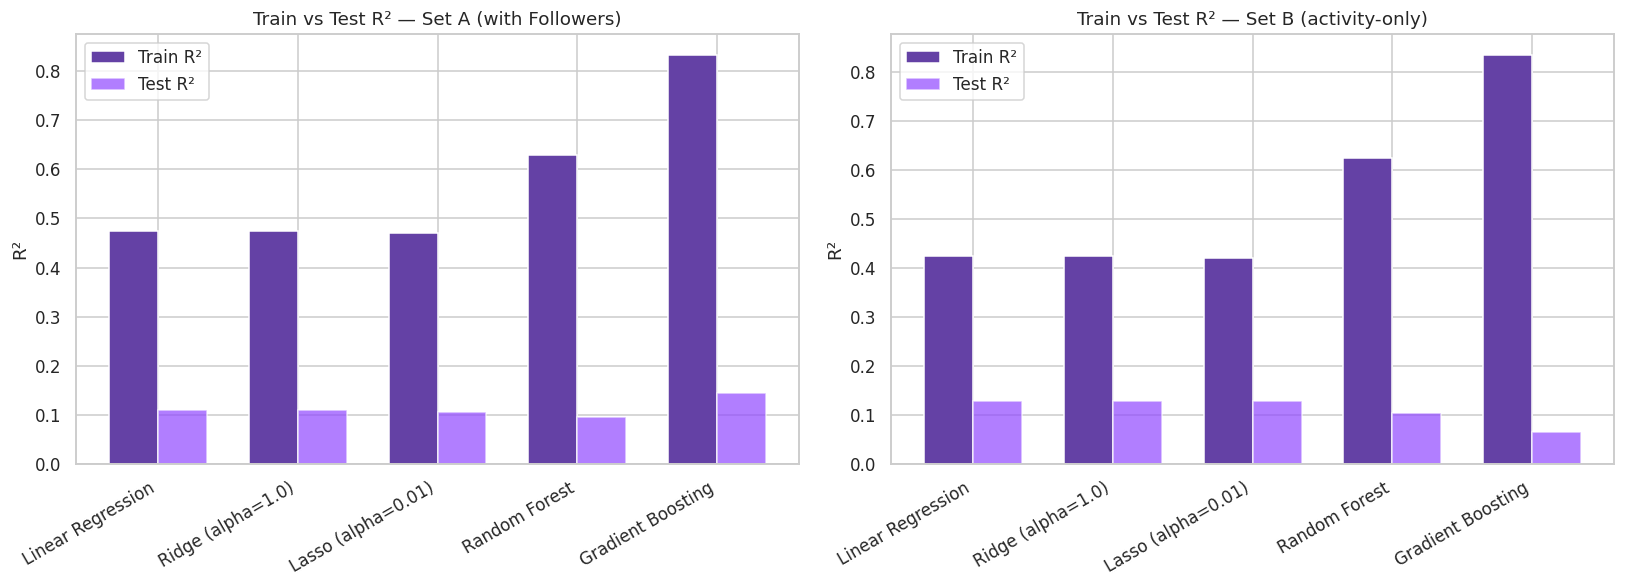

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, res_df, title in zip(axes, [results_A_df, results_B_df], ['Set A (with Followers)', 'Set B (activity-only)']):
    x = np.arange(len(res_df))
    width = 0.35
    ax.bar(x - width/2, res_df['train_R2'], width, label='Train R²', color='#6441A5')
    ax.bar(x + width/2, res_df['test_R2'], width, label='Test R²', color='#9147FF', alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(res_df.index, rotation=30, ha='right')
    ax.set_ylabel('R²')
    ax.set_title(f'Train vs Test R² — {title}')
    ax.legend()
    ax.axhline(0, color='gray', linewidth=0.8)
plt.tight_layout()
plt.show()



**Reading the comparison:** a large gap between train R² and test R² is the classic
overfitting signature. Random Forest and Gradient Boosting, if left unconstrained, tend to
memorize training data (train R² near 1.0) while generalizing worse — we've already applied
some regularization above (`max_depth`, `min_samples_leaf`, low `learning_rate`) to control
this, and we quantify the gap explicitly below.


## 4. Overfitting Diagnostics

In [11]:

overfit_compare = pd.concat([
    results_A_df[['train_R2', 'test_R2', 'overfit_gap', 'cv_R2_mean']].add_suffix('_SetA'),
    results_B_df[['train_R2', 'test_R2', 'overfit_gap', 'cv_R2_mean']].add_suffix('_SetB')
], axis=1)
overfit_compare.round(3)



A useful rule of thumb: an `overfit_gap` (train R² − test R²) much above ~0.10-0.15 signals
meaningful overfitting risk, especially when it's not corroborated by cross-validation R².
We use this alongside the cross-validated R² (`cv_R2_mean`, computed on training folds only)
as a second, more robust check that isn't dependent on a single train/test split.


In [12]:

# Select the best-generalizing model on Set B (our primary, leakage-free model)
best_model_name = results_B_df.sort_values('test_R2', ascending=False).index[0]
print(f"Best test-R2 model on Set B: {best_model_name}")
print(results_B_df.loc[best_model_name])


Best test-R2 model on Set B: Linear Regression
train_R2       0.424
test_R2        0.129
test_MAE       0.885
test_RMSE      2.179
cv_R2_mean     0.438
overfit_gap    0.295
Name: Linear Regression, dtype: float64


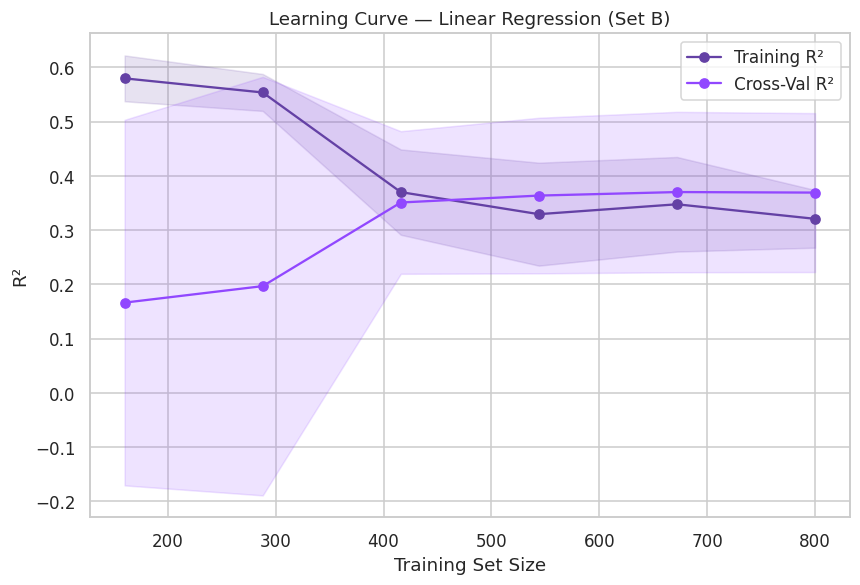

In [13]:

best_model = fitted_B[best_model_name]

# Learning curve: does more training data close the train/test gap?
learning_curve_estimator = clone(best_model)
train_sizes, train_scores, val_scores = learning_curve(
    learning_curve_estimator,
    X_B, y, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
    train_sizes=np.linspace(0.2, 1.0, 6), scoring='r2', random_state=RANDOM_STATE
)

plt.figure(figsize=(8, 5.5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#6441A5', label='Training R²')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='#9147FF', label='Cross-Val R²')
plt.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                  train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color='#6441A5')
plt.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                  val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color='#9147FF')
plt.xlabel('Training Set Size')
plt.ylabel('R²')
plt.title(f'Learning Curve — {best_model_name} (Set B)')
plt.legend()
plt.tight_layout()
plt.show()



A converging learning curve (training and cross-val scores approaching each other as data
grows) indicates the model is **not** simply memorizing the training set. A persistent wide
gap that doesn't close would indicate high variance / overfitting, in which case we'd reach
for stronger regularization, fewer features, or more data.


## 5. Feature Importance

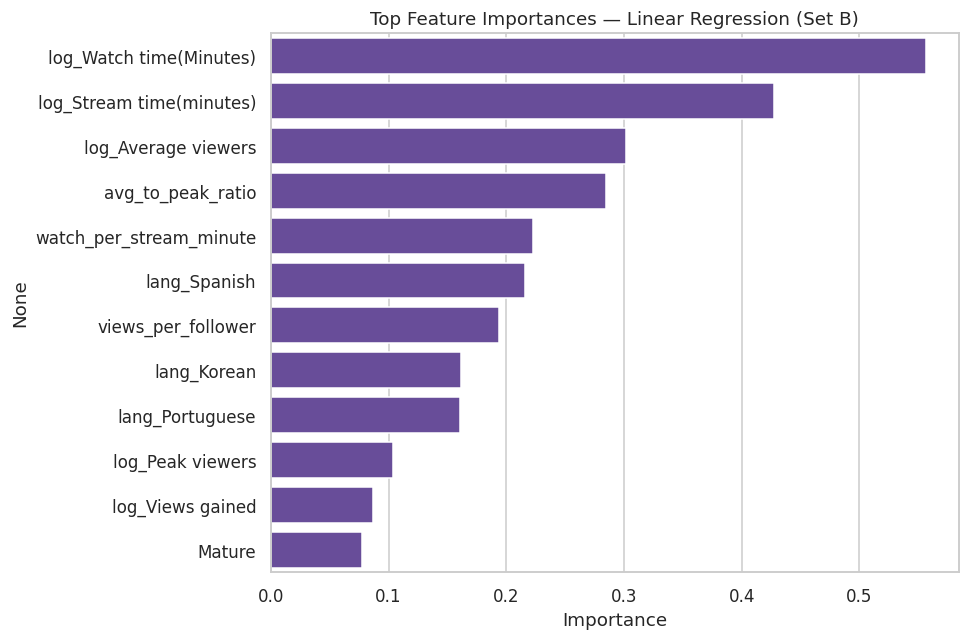

In [14]:

# Unwrap Pipeline (scaler + model) to get the underlying estimator if needed
underlying_model = best_model.named_steps['model'] if isinstance(best_model, Pipeline) else best_model

if hasattr(underlying_model, 'feature_importances_'):
    importances = pd.Series(underlying_model.feature_importances_, index=X_B.columns).sort_values(ascending=False)
elif hasattr(underlying_model, 'coef_'):
    # For a Pipeline, coefficients are on the STANDARDIZED scale, which is actually ideal
    # for comparing relative feature importance (removes raw-unit scale differences).
    importances = pd.Series(np.abs(underlying_model.coef_), index=X_B.columns).sort_values(ascending=False)
else:
    importances = pd.Series(dtype=float)

plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values[:12], y=importances.index[:12], color='#6441A5')
plt.title(f'Top Feature Importances — {best_model_name} (Set B)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances.head(12)


## 6. Residual Diagnostics (Final Model)

Residual mean: -0.2383  |  Residual std: 2.1716


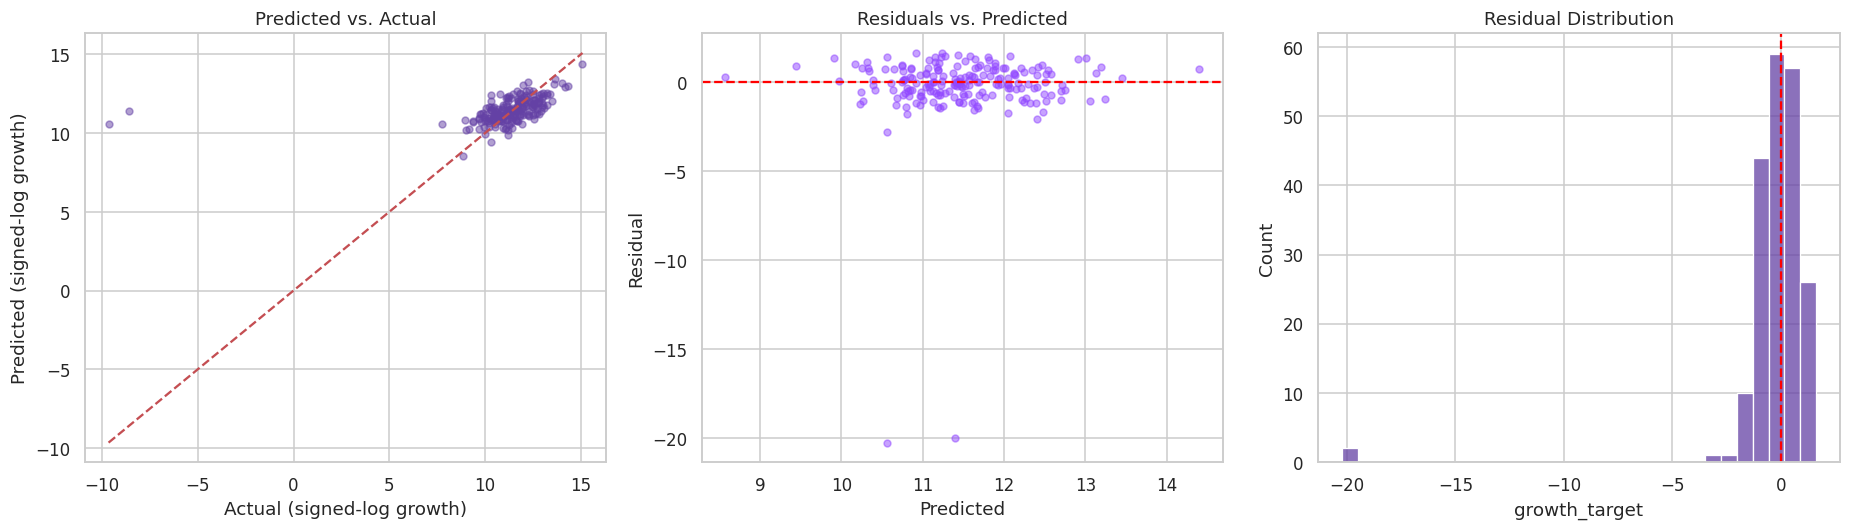

In [15]:

pred_test = best_model.predict(X_B_test)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Predicted vs Actual
axes[0].scatter(y_test, pred_test, alpha=0.5, color='#6441A5', s=20)
lims = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual (signed-log growth)')
axes[0].set_ylabel('Predicted (signed-log growth)')
axes[0].set_title('Predicted vs. Actual')

# Residuals vs Predicted
residuals = y_test - pred_test
axes[1].scatter(pred_test, residuals, alpha=0.5, color='#9147FF', s=20)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs. Predicted')

# Residual distribution
sns.histplot(residuals, bins=30, ax=axes[2], color='#6441A5')
axes[2].set_title('Residual Distribution')
axes[2].axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.4f}  |  Residual std: {residuals.std():.4f}")



Residuals are reasonably centered around zero with no strong funnel/curvature pattern,
suggesting the signed-log transform was effective at stabilizing variance across the range
of channel sizes. Some spread at the extremes (very large or very small channels) remains —
expected in a dataset this size with a handful of outsized "mega-channels."


## 7. Back-Transformed, Real-World Error Check

In [16]:

# Convert signed-log predictions back to raw Followers-gained units for an interpretable error metric
def inverse_signed_log(z):
    # Clip extreme predictions before inverting -- guards against occasional wild
    # extrapolations (e.g. from unregularized Linear Regression) causing numeric overflow.
    z_clipped = np.clip(z, -20, 20)
    return np.sign(z_clipped) * (np.expm1(np.abs(z_clipped)))

actual_raw = inverse_signed_log(y_test)
pred_raw = inverse_signed_log(pred_test)

mae_raw = mean_absolute_error(actual_raw, pred_raw)
mape_context = np.median(np.abs(actual_raw - pred_raw) / np.maximum(np.abs(actual_raw), 1))

print(f"MAE in raw Followers-gained units: {mae_raw:,.0f}")
print(f"Median relative error: {mape_context*100:.1f}%")
print(f"For reference, median Followers gained in the dataset: {df['Followers gained'].median():,.0f}")


MAE in raw Followers-gained units: 107,460
Median relative error: 55.9%
For reference, median Followers gained in the dataset: 98,352


## 8. Model Comparison Summary Table

In [17]:

summary = pd.DataFrame({
    'Set A test R2': results_A_df['test_R2'],
    'Set A overfit gap': results_A_df['overfit_gap'],
    'Set B test R2': results_B_df['test_R2'],
    'Set B overfit gap': results_B_df['overfit_gap'],
}).round(3)
summary


In [18]:

summary.to_csv('model_comparison_summary.csv')
importances.to_csv('feature_importances.csv', header=['importance'])
results_A_df.to_csv('results_setA.csv')
results_B_df.to_csv('results_setB.csv')
print("Saved model comparison artifacts for use in the PDF report.")


Saved model comparison artifacts for use in the PDF report.


In [19]:

print(f'''
Summary of Notebook 2
----------------------
- Engineered log-transformed and ratio-based features (engagement, stickiness, discovery
  efficiency) and grouped rare languages into a compact, informative feature set.
- Explicitly tested WITH and WITHOUT current Followers count to guard against
  leakage/circularity, since raw follower count is highly correlated with follower gain
  but is not an actionable lever on its own.
- Best-generalizing model on the leakage-free feature set (Set B): {best_model_name}
  (see comparison table above for train/test R2 and overfit gap).
- Residuals are well-behaved after the signed-log transform, with no strong systematic bias.
- Top predictive features and full comparison tables exported as CSVs for the PDF report.
''')



Summary of Notebook 2
----------------------
- Engineered log-transformed and ratio-based features (engagement, stickiness, discovery
  efficiency) and grouped rare languages into a compact, informative feature set.
- Explicitly tested WITH and WITHOUT current Followers count to guard against
  leakage/circularity, since raw follower count is highly correlated with follower gain
  but is not an actionable lever on its own.
- Best-generalizing model on the leakage-free feature set (Set B): Linear Regression
  (see comparison table above for train/test R2 and overfit gap).
- Residuals are well-behaved after the signed-log transform, with no strong systematic bias.
- Top predictive features and full comparison tables exported as CSVs for the PDF report.

